In [11]:
!pip install pmdarima

In [12]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error
import warnings
from Метрики.read_functions import get_yield_curve
import joblib

warnings.filterwarnings("ignore")

def fit_arima_fixed_split(df, train_end='2025-11-30', test_end='2025-12-31', max_p=3, max_q=3, filepath="ofz_arima_models.pkl"):
    yield_cols = [c for c in df.columns if c.startswith('bond_ru_ofz_yield')]
    
    df = df.set_index('date').sort_index()
    df = df[~df.index.duplicated(keep='first')]
    
    df = df.loc[:test_end]
    
    train_dt_end = pd.to_datetime(train_end)
    
    train_df = df[df.index <= train_dt_end].copy()
    test_df = df[df.index > train_dt_end].copy()
    
    print(f"Обучение: с {train_df.index.min().date()} по {train_df.index.max().date()}")
    print(f"Тест (Rolling): с {test_df.index.min().date()} по {test_df.index.max().date()}")

    for col in yield_cols:
        train_df[col] = train_df[col].ffill().bfill()
        test_df[col] = test_df[col].ffill().bfill()

    all_results = []
    trained_models = {}

    for col in yield_cols:
        print(f"Анализ {col}...")
        
        train_series = train_df[col]
        test_series = test_df[col]
        
        model = auto_arima(
            train_series,
            max_p=max_p,
            max_q=max_q,
            seasonal=False, 
            stepwise=True,
            suppress_warnings=True
        )
        
        predictions = []
        
        for actual in test_series:
            pred = model.predict(n_periods=1).iloc[0] if isinstance(model.predict(n_periods=1), pd.Series) else model.predict(n_periods=1)[0]
            predictions.append(pred)
            model.update(actual) 
        
        mae = mean_absolute_error(test_series, predictions)
        
        all_results.append({
            'Tenor': col.replace('bond_ru_ofz_yield_', ''),
            'Order (p,d,q)': str(model.order),
            'AIC': round(model.aic(), 2),
            'MAE (п.п.)': round(mae, 4),
            'Last_Train_Yield': round(train_series.iloc[-1], 2),
            'Forecast_Mean': round(np.mean(predictions), 2)
        })
        
        trained_models[col] = {
            'model': model,
            'weights': model.params().tolist(),
            'last_train_date': test_df.index.max() 
        }
        
    joblib.dump(trained_models, filepath)
    print(f"\nМодели успешно сохранены в {filepath}")

    return pd.DataFrame(all_results), trained_models

data = get_yield_curve("Метрики/Таблицы с рядами РФ/Бескупонная доходность ОФЗ.csv")

summary_table, models_dict = fit_arima_fixed_split(
    data, 
    train_end='2025-11-30', 
    test_end='2025-12-31', 
    max_p=4, 
    max_q=5
)

display(summary_table)

Обучение: с 2014-01-06 по 2025-11-28
Тест (Rolling): с 2025-12-01 по 2025-12-30
Анализ bond_ru_ofz_yield_3m...
Анализ bond_ru_ofz_yield_6m...
Анализ bond_ru_ofz_yield_9m...
Анализ bond_ru_ofz_yield_1y...
Анализ bond_ru_ofz_yield_2y...
Анализ bond_ru_ofz_yield_3y...
Анализ bond_ru_ofz_yield_5y...
Анализ bond_ru_ofz_yield_7y...
Анализ bond_ru_ofz_yield_10y...
Анализ bond_ru_ofz_yield_15y...
Анализ bond_ru_ofz_yield_20y...

Модели успешно сохранены в ofz_arima_models.pkl


,Tenor,"Order (p,d,q)",AIC,MAE (п.п.),Last_Train_Yield,Forecast_Mean
0,3m,"(0, 1, 2)",782.92,0.1622,13.23,13.19
1,6m,"(0, 1, 2)",48.93,0.1339,13.55,13.47
2,9m,"(3, 1, 0)",-376.80,0.1114,13.81,13.71
3,1y,"(2, 1, 1)",-688.20,0.0885,14.03,13.90
4,2y,"(2, 1, 5)",-1429.24,0.0792,14.57,14.38
5,3y,"(0, 1, 3)",-1712.23,0.0895,14.78,14.58
6,5y,"(0, 1, 3)",-2079.29,0.0830,14.82,14.64
7,7y,"(0, 1, 3)",-2493.66,0.0620,14.65,14.52
8,10y,"(0, 1, 3)",-3041.44,0.0429,14.33,14.26
9,15y,"(4, 1, 2)",-3243.19,0.0510,13.91,13.87


Запуск Walk-Forward Validation (прогноз на 1 день вперед)...
Финальная модель сохранена в 'var_ofz_model.pkl'

Средняя абсолютная ошибка (MAE) 1-дневных прогнозов за декабрь: 0.0773 п.п.

MAE по срокам (Tenors):
bond_ru_ofz_yield_3m     0.1471
bond_ru_ofz_yield_6m     0.1199
bond_ru_ofz_yield_9m     0.1023
bond_ru_ofz_yield_1y     0.0864
bond_ru_ofz_yield_2y     0.0717
bond_ru_ofz_yield_3y     0.0725
bond_ru_ofz_yield_5y     0.0647
bond_ru_ofz_yield_7y     0.0477
bond_ru_ofz_yield_10y    0.0362
bond_ru_ofz_yield_15y    0.0471
bond_ru_ofz_yield_20y    0.0546
dtype: float64


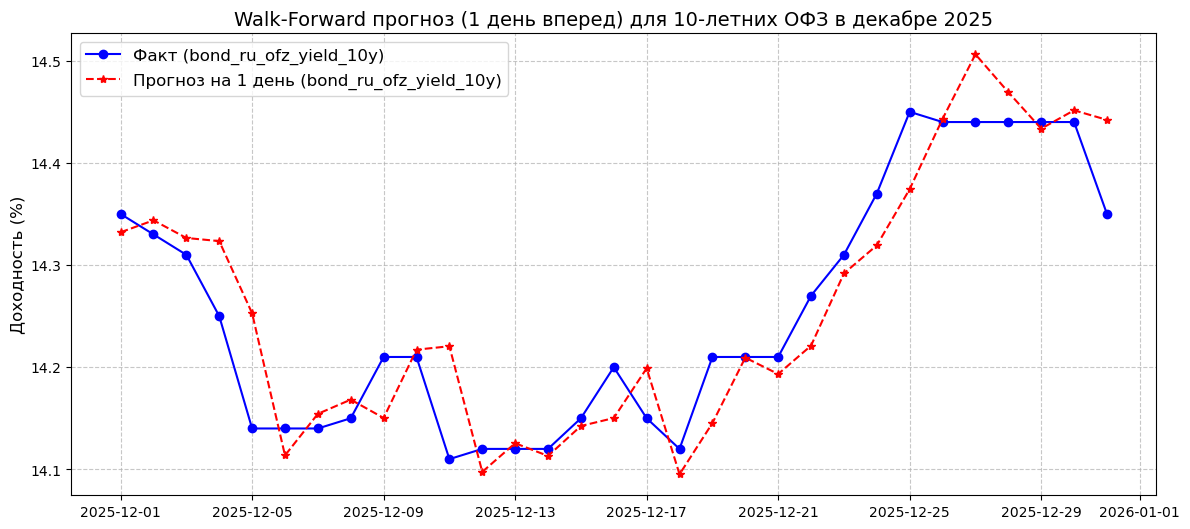

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
import warnings
import joblib
from Метрики.read_functions import dict_func

warnings.filterwarnings('ignore')

df_stat = pd.read_csv('Метрики/master_df_daily_stationary.csv', index_col=0, parse_dates=True)

ofz_cols = [f'bond_ru_ofz_yield_{m}' for m in ['3m', '6m', '9m', '1y', '2y', '3y', '5y', '7y', '10y', '15y', '20y']]
macro_cols = [
    'macro_ru_key_rate',
    'macro_ru_ruonia_rate',
    'macro_ru_cpi_food_yoy',
    'brent_price',
    'bond_ru_corp_yield',
    'bond_ru_corp_price_close',
    'macro_kz_base_rate',
    'bond_kz_govt_cp_total',
]

target_cols = ofz_cols + macro_cols
df_model = df_stat[target_cols].copy()

optimal_lags = {
    'macro_ru_key_rate': 23,
    'macro_kz_base_rate': 53,
    'macro_ru_ruonia_rate': 1,
    'macro_ru_cpi_food_yoy': 53,
    'brent_price': 0,
    'bond_ru_corp_yield': 0,
    'bond_ru_corp_price_close': 0,
    'bond_kz_govt_cp_total': 28,
}

for col, lag in optimal_lags.items():
    if lag > 0:
        df_model[col] = df_model[col].shift(lag)

df_model = df_model.dropna()

def get_raw_levels():
    all_dfs = []
    for path, func in dict_func.items():
        try:
            temp_df = func(f'Метрики/{path}')
            temp_df['date'] = pd.to_datetime(temp_df['date'])
            all_dfs.append(temp_df.set_index('date'))
        except: 
            pass
    raw_master = pd.concat(all_dfs, axis=1).resample('D').ffill().bfill()
    return raw_master

df_raw = get_raw_levels()
raw_ofz = df_raw[ofz_cols].resample('D').ffill().bfill()

history_end_date = pd.to_datetime('2025-11-30')
history_stat = df_model.loc[:history_end_date].copy()

test_stat = df_model.loc['2025-12-01':'2025-12-31']

predictions_levels = []
actual_levels = []

print("Запуск Walk-Forward Validation (прогноз на 1 день вперед)...")

for date, row in test_stat.iterrows():
    model = VAR(history_stat)
    results = model.fit(maxlags=3, ic='aic')
    
    forecast_diff = results.forecast(history_stat.values[-results.k_ar:], steps=1)
    delta_pred = forecast_diff[0][:len(ofz_cols)] 
    
    yesterday = date - pd.Timedelta(days=1)
    yesterday_level = raw_ofz.loc[:yesterday].iloc[-1].values 
    
    today_pred_level = yesterday_level + delta_pred
    predictions_levels.append(today_pred_level)
    actual_levels.append(raw_ofz.loc[date].values)
    
    history_stat = pd.concat([history_stat, pd.DataFrame(row).T])

joblib.dump(results, 'var_ofz_model.pkl')
print("Финальная модель сохранена в 'var_ofz_model.pkl'")

df_pred_levels = pd.DataFrame(predictions_levels, index=test_stat.index, columns=ofz_cols)
df_fact_levels = pd.DataFrame(actual_levels, index=test_stat.index, columns=ofz_cols)

mae_per_tenor = np.abs(df_pred_levels - df_fact_levels).mean()
overall_mae = mae_per_tenor.mean()

print(f"\nСредняя абсолютная ошибка (MAE) 1-дневных прогнозов за декабрь: {overall_mae:.4f} п.п.")
print("\nMAE по срокам (Tenors):")
print(mae_per_tenor.round(4))

target_tenor = 'bond_ru_ofz_yield_10y'

plt.figure(figsize=(14, 6))
plt.plot(df_fact_levels.index, df_fact_levels[target_tenor], 'bo-', label=f'Факт ({target_tenor})')
plt.plot(df_pred_levels.index, df_pred_levels[target_tenor], 'r*--', label=f'Прогноз на 1 день ({target_tenor})')

plt.title(f"Walk-Forward прогноз (1 день вперед) для 10-летних ОФЗ в декабре 2025", fontsize=14)
plt.ylabel("Доходность (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.show()

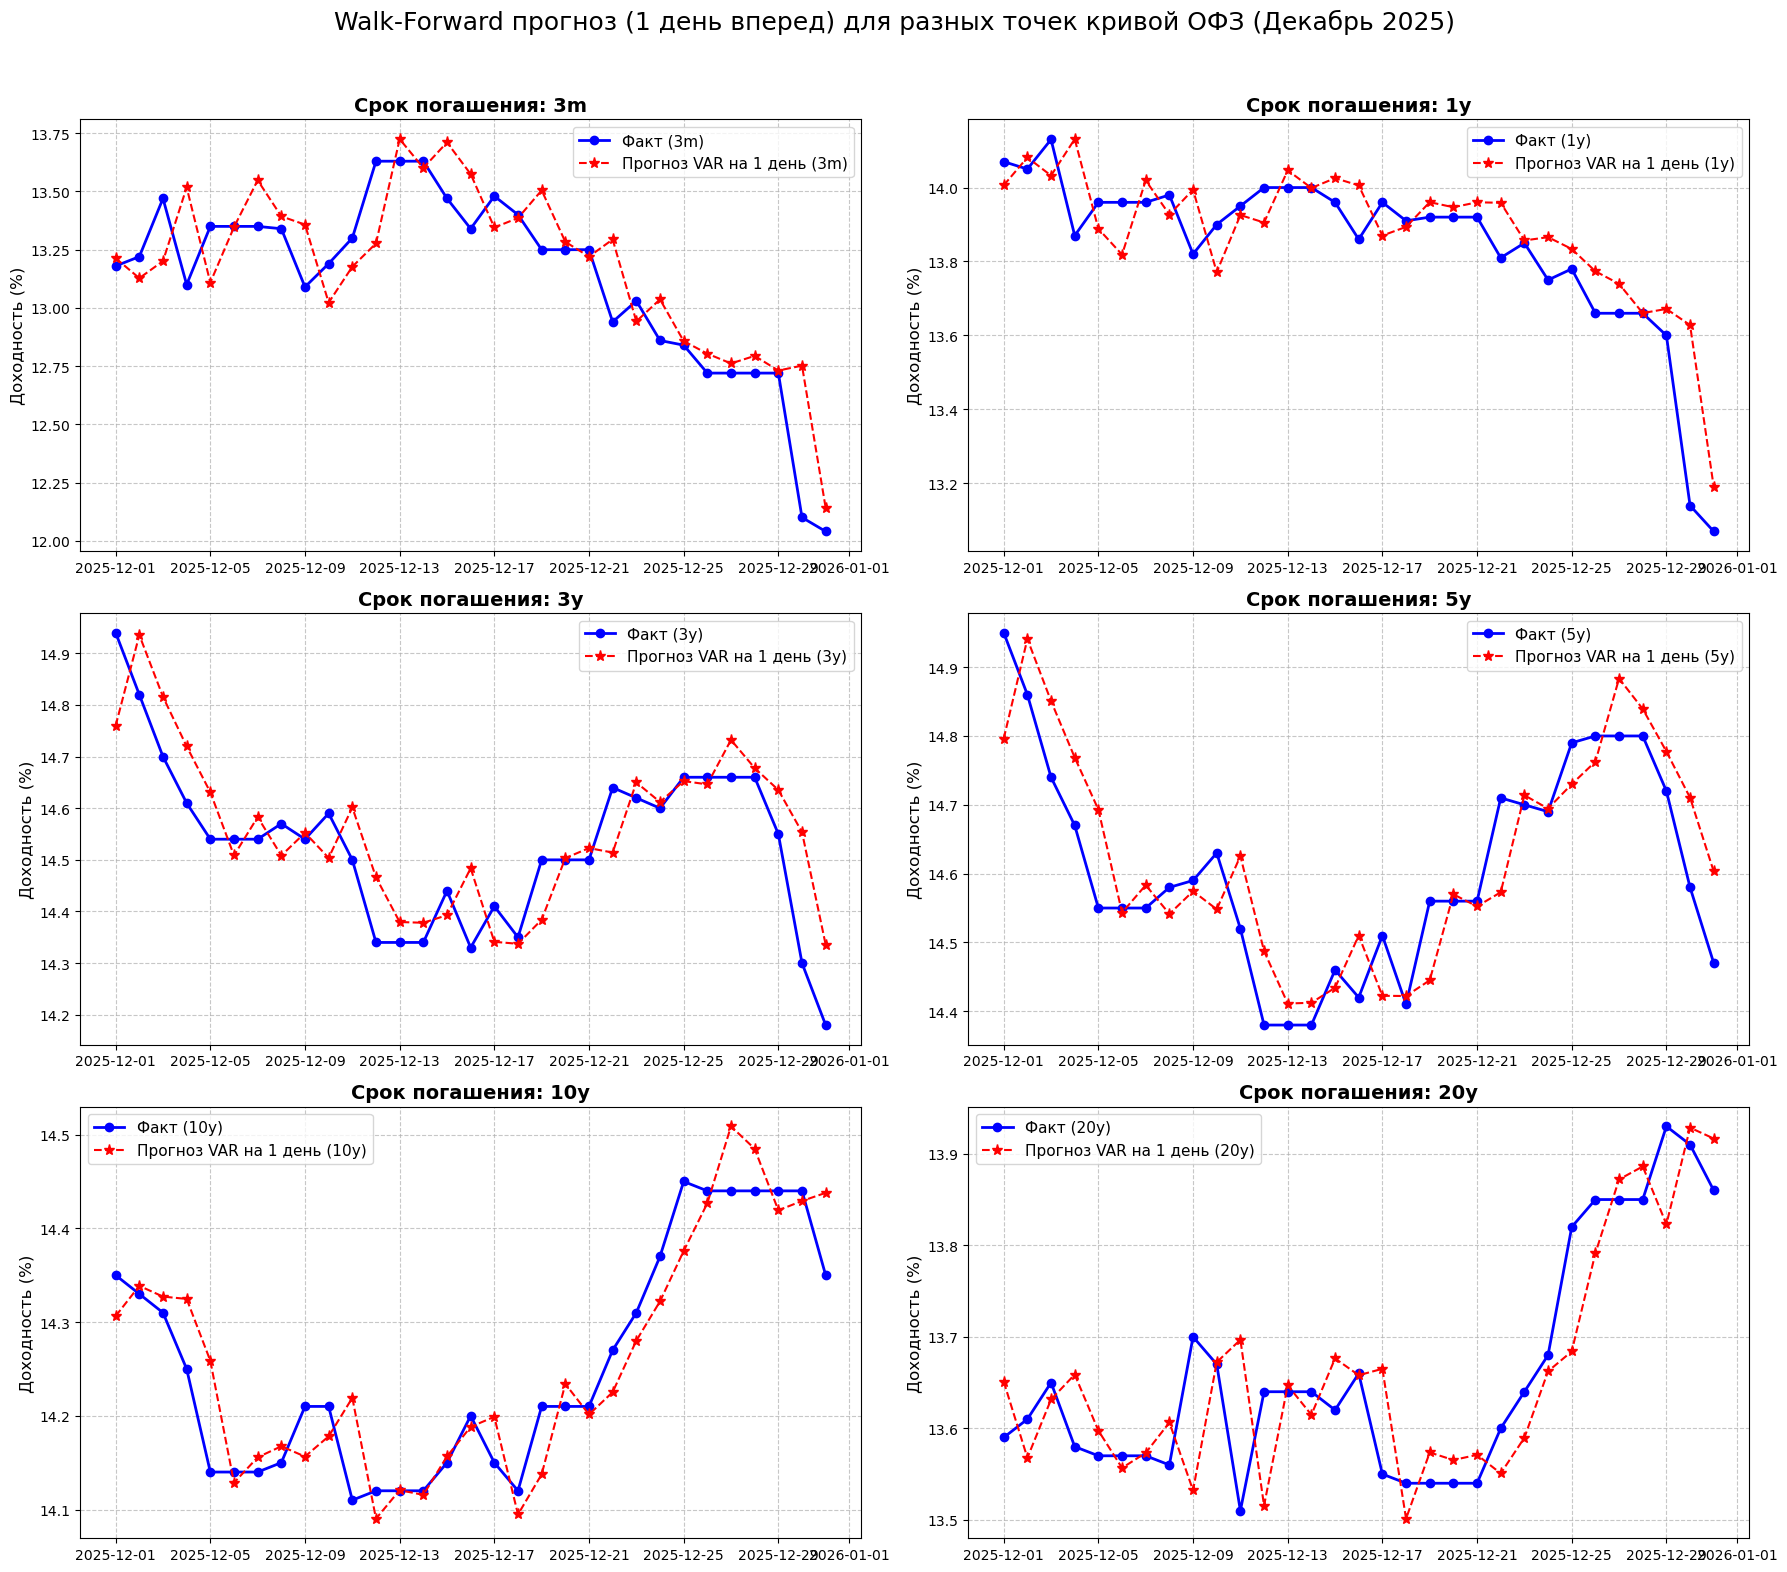

In [16]:
import matplotlib.pyplot as plt

tenors_to_plot = ['3m', '1y', '3y', '5y', '10y', '20y']

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

for i, tenor in enumerate(tenors_to_plot):
    col = f'bond_ru_ofz_yield_{tenor}'
    ax = axes[i]
    
    ax.plot(df_fact_levels.index, df_fact_levels[col], 'bo-', label=f'Факт ({tenor})', linewidth=2)
    ax.plot(df_pred_levels.index, df_pred_levels[col], 'r*--', label=f'Прогноз VAR на 1 день ({tenor})', markersize=8)
    
    ax.set_title(f'Срок погашения: {tenor}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Доходность (%)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(fontsize=11)

plt.suptitle("Walk-Forward прогноз (1 день вперед) для разных точек кривой ОФЗ (Декабрь 2025)", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()